In [21]:
# task-1 : Data Acquisition & loading the datset

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("database.csv")

print("Original Shape:", df.shape)
df.head()

Original Shape: (46185, 14)


,Declaration Number,Declaration Type,Declaration Date,State,County,Disaster Type,Disaster Title,Start Date,End Date,Close Date,Individual Assistance Program,Individuals & Households Program,Public Assistance Program,Hazard Mitigation Program
0,DR-1,Disaster,05/02/1953,GA,NaN,Tornado,Tornado,05/02/1953,05/02/1953,06/01/1954,Yes,No,Yes,Yes
1,DR-2,Disaster,05/15/1953,TX,NaN,Tornado,Tornado and Heavy Rainfall,05/15/1953,05/15/1953,01/01/1958,Yes,No,Yes,Yes
2,DR-3,Disaster,05/29/1953,LA,NaN,Flood,Flood,05/29/1953,05/29/1953,02/01/1960,Yes,No,Yes,Yes
3,DR-4,Disaster,06/02/1953,MI,NaN,Tornado,Tornado,06/02/1953,06/02/1953,02/01/1956,Yes,No,Yes,Yes
4,DR-5,Disaster,06/06/1953,MT,NaN,Flood,Floods,06/06/1953,06/06/1953,12/01/1955,Yes,No,Yes,Yes


In [22]:
#Task -2 : Data Understanding
df.info()
df.describe()
df.isnull().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 46185 entries, 0 to 46184
Data columns (total 14 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Declaration Number                46185 non-null  object
 1   Declaration Type                  46185 non-null  object
 2   Declaration Date                  46185 non-null  object
 3   State                             46185 non-null  object
 4   County                            45988 non-null  object
 5   Disaster Type                     46185 non-null  object
 6   Disaster Title                    46185 non-null  object
 7   Start Date                        46185 non-null  object
 8   End Date                          45843 non-null  object
 9   Close Date                        35210 non-null  object
 10  Individual Assistance Program     46185 non-null  object
 11  Individuals & Households Program  46185 non-null  object
 12  Public Assistance 

Declaration Number                      0
Declaration Type                        0
Declaration Date                        0
State                                   0
County                                197
Disaster Type                           0
Disaster Title                          0
Start Date                              0
End Date                              342
Close Date                          10975
Individual Assistance Program           0
Individuals & Households Program        0
Public Assistance Program               0
Hazard Mitigation Program               0
dtype: int64

In [23]:
#Task -3 : Data Cleaning

In [24]:
#3.1 - Remove Exact Duplicates
df = df.drop_duplicates()
print("After removing exact duplicates:", df.shape)

After removing exact duplicates: (46185, 14)


In [25]:
#3.2-Keep Unique Disaster Declarations

df = df.drop_duplicates(subset=['Declaration Number'])
print("After keeping unique disasters:", df.shape)

After keeping unique disasters: (3427, 14)


In [26]:
#3.3-Convert Date Columns
df['Start Date'] = pd.to_datetime(df['Start Date'], errors='coerce')
df['End Date'] = pd.to_datetime(df['End Date'], errors='coerce')
df['Close Date'] = pd.to_datetime(df['Close Date'], errors='coerce')

In [27]:
#3.4-Remove Missing Start Dates

df = df.dropna(subset=['Start Date'])

In [28]:
#3.5-Standardize Categorical Fields
df['Disaster Type'] = df['Disaster Type'].str.upper().str.strip()
df['State'] = df['State'].str.upper().str.strip()

In [29]:
#3.6-Feature Engineering (Extract Date Features)
df['Year'] = df['Start Date'].dt.year
df['Month'] = df['Start Date'].dt.month
df['Month_Name'] = df['Start Date'].dt.month_name()

In [30]:
#3.7 Create Duration Variable
df['Duration_Days'] = (df['End Date'] - df['Start Date']).dt.days
df = df[df['Duration_Days'] >= 0]

In [31]:
#Task-4 
#4.1 Disaster Declarations Per Year
yearly = df.groupby('Year')['Declaration Number'].nunique()
print(yearly.head())

Year
1953    13
1954    17
1955    18
1956    16
1957    16
Name: Declaration Number, dtype: int64


In [32]:
#4.2-Disaster Count Per State
state_counts = df['State'].value_counts()
print(state_counts.head())

State
TX    221
CA    193
OK    123
WA     94
NY     93
Name: count, dtype: int64


In [33]:
#4.3-Disaster Type Frequency
type_counts = df['Disaster Type'].value_counts()
print(type_counts.head())

Disaster Type
STORM        923
FLOOD        773
FIRE         639
HURRICANE    313
TORNADO      163
Name: count, dtype: int64


In [34]:
df.describe()
df['Disaster Type'].value_counts()
df['State'].value_counts().head(10)

State
TX    221
CA    193
OK    123
WA     94
NY     93
FL     86
LA     76
AL     71
NM     71
CO     70
Name: count, dtype: int64

In [35]:
#Task - 5 : Data Visualization

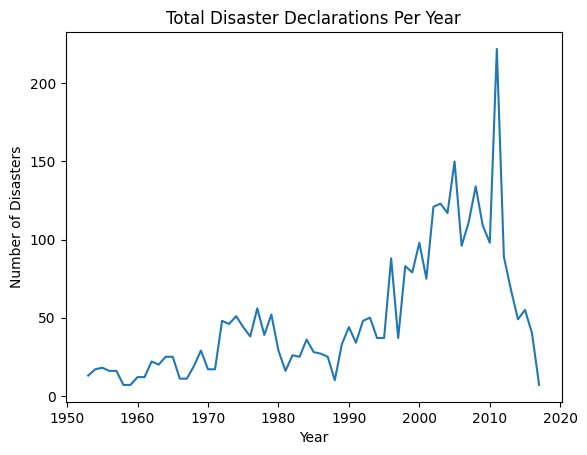

In [36]:
#5.1-Time-Series Plot (Declarations Per Year)

plt.figure()
yearly.plot()
plt.title("Total Disaster Declarations Per Year")
plt.xlabel("Year")
plt.ylabel("Number of Disasters")
plt.show()

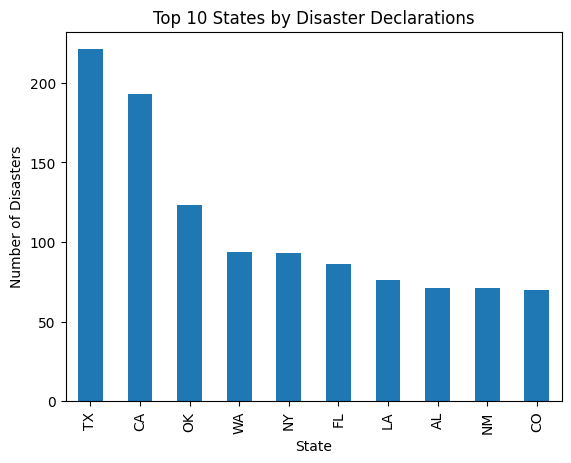

In [37]:
#5.2-Bar Chart (Declarations Per State)

plt.figure()
state_counts.head(10).plot(kind='bar')
plt.title("Top 10 States by Disaster Declarations")
plt.xlabel("State")
plt.ylabel("Number of Disasters")
plt.show()

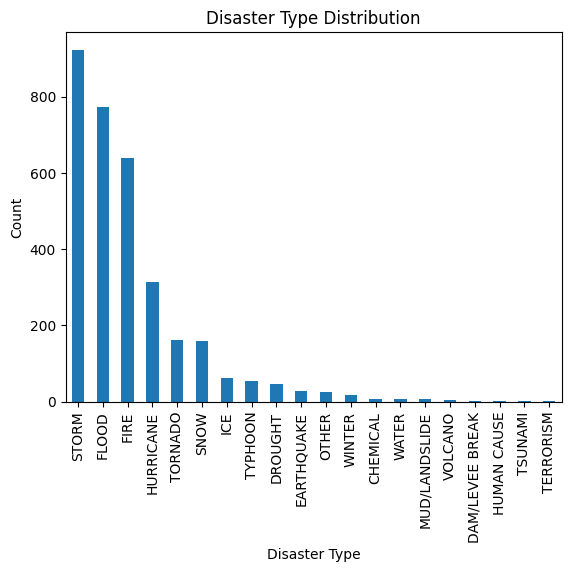

In [38]:
#3-Disaster Type Distribution

plt.figure()
df['Disaster Type'].value_counts().plot(kind='bar')
plt.title("Disaster Type Distribution")
plt.xlabel("Disaster Type")
plt.ylabel("Count")
plt.xticks(rotation=90)
plt.show()

In [39]:
#Creating a clenaed dataset without any duplicates adn missing values for future use

cleaned_df = df[[
    'Declaration Number',
    'State',
    'Disaster Type',
    'Start Date',
    'End Date',
    'Close Date',
    'Year',
    'Month',
    'Month_Name',
    'Duration_Days'
]]

cleaned_df.to_csv("cleaned_disaster_dataset.csv", index=False)

print("Cleaned dataset saved successfully.")

Cleaned dataset saved successfully.
